In [1]:
from utils import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import numpy as np
from pyepo.data.dataset import optDataset
import tensorflow as tf

I0000 00:00:1776826332.115997 1800801 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
random.seed(42)

num_data = 2000
num_feat = 3
d=40
w = np.random.uniform(low=0, high=1, size=(3, d))
a = np.random.normal(loc=np.linspace(2, 6, d), scale=1, size=(d))
optmodel = shortestPathModel(grid=(5,5))

X, Y = getdata(num_data, a, w)
X, Xtest, Y, Ytest = train_test_split(X, Y, test_size=0.25)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2610491
Academic license 2610491 - for non-commercial use only - registered to ry___@usc.edu


In [4]:
def random_unexplored(seed = 42):
    random.seed(seed)
    exploredpaths = []
    while len(exploredpaths) == 0:
        unexplorable = random.sample(range(40), 4)
        exploredpaths, unexploredpaths = get_paths(unexplorable=unexplorable)
    return exploredpaths, unexploredpaths

### Main Experiments: Imputing Data

In [ ]:
def experiment(X, Xtest, Y, Ytest, unexplorable, valratio = 1, inputrationality = None, imputecopies = 50, nuisance_epochs = 300, nuisance_lam = 1, dfl_epochs = 50, pgsigma = 0.5, dataseed=42, pathseed=42):
    # Impute a constant according to valratio

    if unexplorable is not None:
        exploredpaths, unexploredpaths = get_paths(unexplorable=unexplorable)
    else:
        exploredpaths, unexploredpaths = random_unexplored(pathseed)

    
    dataset = BanditDataset(X, Y, exploredpaths, inputrationality, seed=dataseed)
    trainset = BanditDataset(X, Y, exploredpaths, inputrationality, seed=dataseed)
    rationality = get_rationality(dataset)
    unexplored = get_unexplored(dataset)
    val = valratio * max(dataset.c)
    imputeset = ValImputeDataset(X, Y, unexplored, val, copies=imputecopies, seed=dataseed) # Constant cost imputed data
    trainset.append(imputeset)
    nuisance = learn_nuisance(trainset, nuisance_epochs, lam=nuisance_lam)
    gram = learn_gram(trainset)

    testset = optDataset(optmodel, Xtest, Ytest)
    Ypred = torch.stack([thetadr(dataset.x[i], dataset.z[i], dataset.c[i], nuisance, gram, reg=True) for i in range(len(dataset.x))])
    trainset = optDataset(optmodel, dataset.x, Ypred.detach().numpy())

    predmodel, trainregret, testregret = learn_dfl(trainset, testset, num_epochs=dfl_epochs, sigma=pgsigma, allregrets=False)

    return predmodel, trainregret, testregret, rationality

In [ ]:
def experiment2(X, Xtest, Y, Ytest, unexplorable, inputrationality = None, imputeamount = 50, nuisance_epochs = 300, nuisance_lam = 1, dfl_epochs = 50, pgsigma = 0.5, dataseed=42, pathseed=42, noise = 0):
    # Impute from the same distribution, but apply noise to the observed costs in the imputed data

    if unexplorable is not None:
        exploredpaths, _ = get_paths(unexplorable=unexplorable)
    else:
        exploredpaths, _ = random_unexplored(pathseed)

    Ximpute, _, Yimpute, _ = train_test_split(X, Y, train_size = imputeamount)
    
    dataset = BanditDataset(X, Y, exploredpaths, inputrationality, seed=dataseed)
    trainset = BanditDataset(X, Y, exploredpaths, inputrationality, seed=dataseed)
    rationality = get_rationality(dataset)
    unexploredpaths = dataset.get_unexplored()
    imputeset = BanditDataset(Ximpute, Yimpute, unexploredpaths, seed=dataseed, noise=noise) # Noisy imputed data
    trainset.append(imputeset)
    nuisance = learn_nuisance(trainset, nuisance_epochs, lam=nuisance_lam)
    gram = learn_gram(trainset)

    testset = optDataset(optmodel, Xtest, Ytest)
    Ypred = torch.stack([thetadr(dataset.x[i], dataset.z[i], dataset.c[i], nuisance, gram, reg=True) for i in range(len(dataset.x))])
    trainset = optDataset(optmodel, dataset.x, Ypred.detach().numpy())

    predmodel, trainregret, testregret = learn_dfl(trainset, testset, num_epochs=dfl_epochs, sigma=pgsigma, allregrets=False)

    return predmodel, trainregret, testregret, rationality

In [18]:
amts = np.linspace(1, 11, 11)
inputrationalities = np.linspace(0, 1, 11)

amounts=[]
regrets = []
rationalities = []
for amt in amts:
    for r in inputrationalities:
        for i in range(1):
            predmodel, trainregret, testregret, rationality = experiment2(X, Xtest, Y, Ytest, [], inputrationality=r, dataseed=i, nuisance_lam=0, imputeamount=int(50*amt))
            rationalities.append(rationality)
            regrets.append(testregret)
            amounts.append(50 * amt)



Optimizing for optDataset...


100%|██████████| 1500/1500 [00:00<00:00, 2408.99it/s]


Optimizing for optDataset...



100%|██████████| 1500/1500 [00:00<00:00, 2453.69it/s]


Learning fnuisance function...


...

/home/redmonds/miniconda3/envs/e2e/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
100%|██████████| 500/500 [00:00<00:00, 2066.97it/s]



Optimizing for optDataset...


100%|██████████| 1500/1500 [00:00<00:00, 2369.72it/s]

Num of cores: 2

Learning final policy...


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
rationalities = np.array(rationalities).flatten()
# vals = np.array(vals).flatten()
amounts = np.array(amounts).flatten()
regrets = np.array(regrets).flatten()

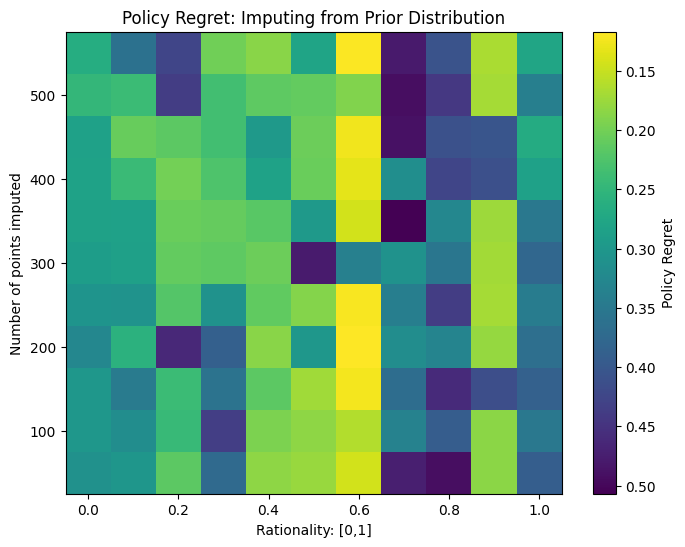

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming rationalities, vals, and regrets are defined from your earlier cells
# If not, ensure they're loaded/recomputed here

# Define the number of bins for the grid (adjust as needed for resolution)
num_bins = 11  # More bins = finer grid, but may over-smooth sparse data

# Create bin edges for rationality (x-axis) and imputed values (y-axis)
x_bins = np.linspace(min(rationalities), max(rationalities), num_bins + 1)
x_bins = np.linspace(-0.05, 1.05, num_bins + 1)
y_bins = np.linspace(25, 575, num_bins + 1)
# scaledregrets = [(maxr-r)/(maxr-minr) for r in regrets]
# Compute the 2D histogram: sum of regrets per bin
hist_regret_sum, x_edges, y_edges = np.histogram2d(
    rationalities, amounts, bins=[x_bins, y_bins], weights=regrets
)

# Compute the 2D histogram: count of points per bin
hist_counts, _, _ = np.histogram2d(rationalities, amounts, bins=[x_bins, y_bins])

# Compute mean regret per bin (avoid division by zero)
mean_regret = np.divide(
    hist_regret_sum, hist_counts, 
    out=np.zeros_like(hist_regret_sum),  # Fill empty bins with 0
    where=hist_counts != 0
)

# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust size as needed
plt.pcolormesh(
    x_edges, y_edges, mean_regret.T,  # Transpose for correct orientation
    cmap='viridis_r',  # Reverse colormap so lower regret appears brighter/cooler
    shading='flat'  # Ensures bin edges align
)
# plt.colorbar(label='Mean Regret (lower is better)')  # Add colorbar with label
cbar = plt.colorbar(label='Policy Regret')
cbar.ax.invert_yaxis()
plt.xlabel("Rationality: [0,1]")
plt.ylabel("Number of points imputed")
plt.title("Policy Regret: Imputing from Prior Distribution")
plt.show()

### Baseline Experiment: How does regularization perform?

In [50]:
dataseed=42
imputecopies=50
nuisance_lam=1
nuisance_epochs=300
dfl_epochs=50
pgsigma=0.5

out=[]

for r in inputrationalities:
    exploredpaths, unexploredpaths = get_paths()

    
    dataset = BanditDataset(X, Y, exploredpaths, r, seed=dataseed)
    rationality = get_rationality(dataset)
    unexplored = get_unexplored(dataset)
    nuisance = learn_nuisance(dataset, nuisance_epochs, lam=nuisance_lam)
    gram = learn_gram(dataset)

    testset = optDataset(optmodel, Xtest, Ytest)
    Ypred = torch.stack([thetadr(dataset.x[i], dataset.z[i], dataset.c[i], nuisance, gram, reg=True) for i in range(len(dataset.x))])
    trainset = optDataset(optmodel, dataset.x, Ypred.detach().numpy())

    predmodel, trainregret, testregret = learn_dfl(trainset, testset, num_epochs=dfl_epochs, sigma=pgsigma, allregrets=False)
    out.append(testregret)



Optimizing for optDataset...


100%|██████████| 1500/1500 [00:00<00:00, 2287.36it/s]


Optimizing for optDataset...



100%|██████████| 1500/1500 [00:00<00:00, 2286.50it/s]


Learning fnuisance function...


...

/home/redmonds/miniconda3/envs/e2e/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
100%|██████████| 500/500 [00:00<00:00, 2317.67it/s]



Optimizing for optDataset...


100%|██████████| 1500/1500 [00:00<00:00, 2435.88it/s]

Num of cores: 2

Learning final policy...


  0%|          | 0/50 [00:00<?, ?it/s]

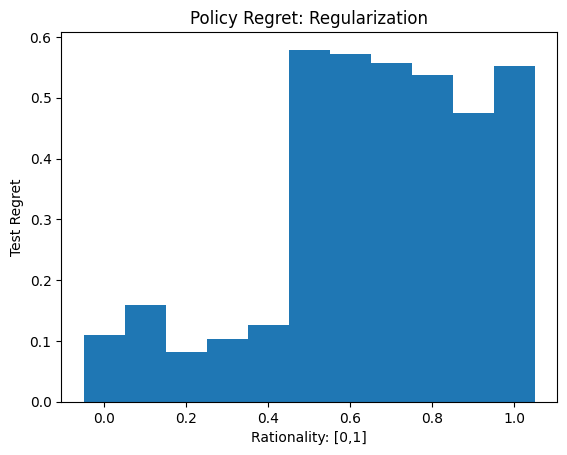

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'out' is defined from the previous cell
x = np.linspace(0, 1, 11)
plt.bar(x, out, width=.1, align='center')  # Bars touch each other with no whitespace
plt.xlabel("Rationality: [0,1]")
plt.ylabel('Test Regret')
plt.title('Policy Regret: Regularization')
plt.show()